In [1]:
# Moltiverse- analysis  *** Written by FJ at AIME lab

In [7]:
## glob.glob("<path_to_sdf_files>/*_qm.sdf")  ## path to :*_qm.sdf sdf_file
sdf_file = "protac1_qm.sdf"  
protac_name = "PROTAC_1" # Protac ID 
name_prefix = "MV"  # Name prefix for output files

In [8]:
# 3D of the SDF File Ensemble
from rdkit import Chem
import py3Dmol
import ipywidgets as widgets
from ipywidgets import interact

# Load conformers 
if "mols" not in globals():
    supplier = Chem.SDMolSupplier(sdf_file, removeHs=False) #removeHs=False
    mols = [mol for mol in supplier if mol is not None]

if not mols:
    raise ValueError(f"No valid molecules found in {sdf_file}")

# Define viewer helper
if "MolTo3DView" not in globals():
    def MolTo3DView(mol, style='stick'):
        mb = Chem.MolToMolBlock(mol)
        viewer = py3Dmol.view(width=400, height=400)
        viewer.addModel(mb, 'mol')
        viewer.setStyle({style: {}})
        viewer.setBackgroundColor('white')
        viewer.zoomTo()
        return viewer

if "view_conformer" not in globals():
    def view_conformer(idx1, style):
        mol = mols[idx1 - 1]  # Convert to 0-based index
        return MolTo3DView(mol, style).show()

# Display widget
interact(
    view_conformer,
    idx1=widgets.IntSlider(min=1, max=len(mols), step=1, value=1, description='Conformer'),
    style=widgets.Dropdown(
        options=['line', 'stick', 'sphere'],
        value='stick',
        description='Style:'
    )
)

interactive(children=(IntSlider(value=1, description='Conformer', max=250, min=1), Dropdown(description='Style…

<function __main__.view_conformer(idx1, style)>

In [9]:
####### SASA and Rg calculation #########

import os
import tempfile
import pandas as pd
import mdtraj as md
from rdkit import Chem
from rdkit.Chem import rdmolfiles, rdMolDescriptors

output_csv = f"sasa_rg_{protac_name.lower()}.csv"

suppl = Chem.SDMolSupplier(str(sdf_file), removeHs=False)
results = []

for i, mol in enumerate(suppl):
    if mol is None:
        continue

    pdb_filename = f"{name_prefix}_{i}.pdb"

    try:
        Chem.rdmolfiles.MolToPDBFile(mol, pdb_filename)
        traj = md.load(pdb_filename)

        # MDTraj SASA is nm² → convert to Å²
        sasa_nm2 = md.shrake_rupley(traj).sum(axis=1)[0]
        sasa_A2 = sasa_nm2 * 100.0

        # RDKit Rg is Å
        rg_A = rdMolDescriptors.CalcRadiusOfGyration(mol)

        conformer_id = mol.GetProp("conformer_id") if mol.HasProp("conformer_id") else i
        results.append((conformer_id, sasa_A2, rg_A))

    except Exception as e:
        print(f"Error in molecule {i}: {e}")

    finally:
        if os.path.exists(pdb_filename):
            os.remove(pdb_filename)

df = pd.DataFrame(results, columns=["conformer_id", "SASA_A2", "Rg_A"])

df["conformer_id"] = pd.to_numeric(df["conformer_id"], errors="coerce")
df = df.dropna(subset=["conformer_id"])
df = df.sort_values("conformer_id")

df.to_csv(output_csv, index=False)

print(f"✅ Results saved to {output_csv}")

✅ Results saved to sasa_rg_protac_1.csv


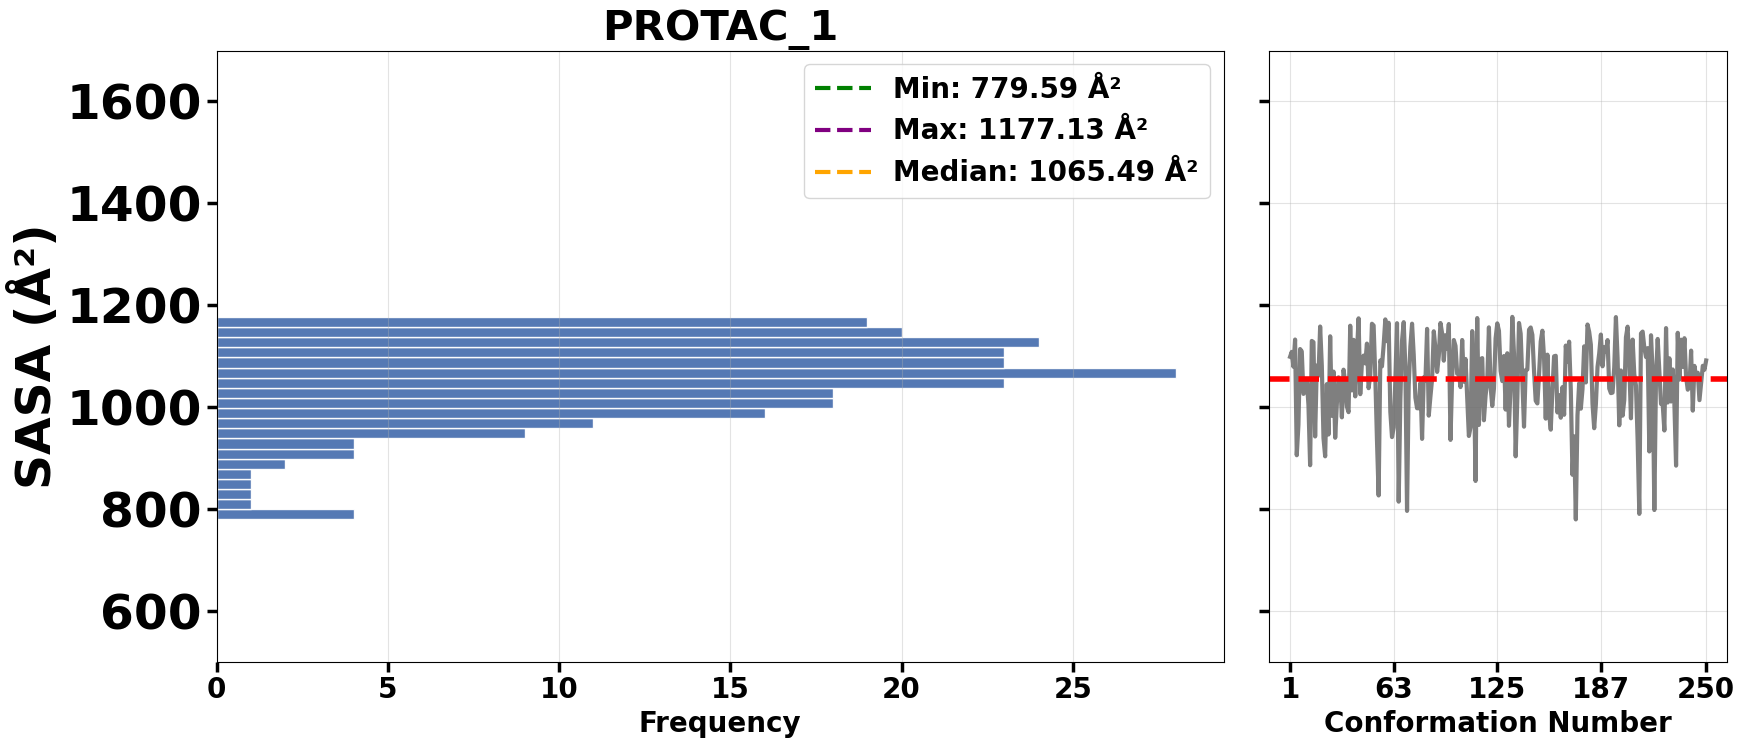

In [10]:
####### SASA Histogram and Line Plot #########

import numpy as np
import matplotlib.pyplot as plt

# Set the limits for the SASA histogram and line plot
XLIM_SASA = None   
YLIM_SASA = (500, 1700)

hist_color = "#4C72B0"

min_sasa = df["SASA_A2"].min()
max_sasa = df["SASA_A2"].max()
median_sasa = df["SASA_A2"].median()
mean_sasa = df["SASA_A2"].mean()

plt.rcParams.update({
    "font.size": 24,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 30,
    "axes.labelsize": 32,
    "xtick.labelsize": 20,
    "ytick.labelsize": 35,
    "legend.fontsize": 20,
})

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]}
)

ax[0].hist(
    df["SASA_A2"],
    bins=20,
    orientation="horizontal",
    color=hist_color,
    edgecolor="white",
    alpha=0.95
)

ax[0].plot([], [], color="green", linestyle="--", linewidth=3,
           label=f"Min: {min_sasa:.2f} Å²")
ax[0].plot([], [], color="purple", linestyle="--", linewidth=3,
           label=f"Max: {max_sasa:.2f} Å²")
ax[0].plot([], [], color="orange", linestyle="--", linewidth=3,
           label=f"Median: {median_sasa:.2f} Å²")

ax[0].set_title(f"{protac_name}", fontweight="bold")
ax[0].set_xlabel("Frequency", fontweight="bold", fontsize=20)
ax[0].set_ylabel("SASA (Å²)", fontweight="bold", fontsize=35)
ax[0].grid(axis="x", alpha=0.35)
ax[0].legend(loc="upper right")

if YLIM_SASA is not None:
    ax[0].set_ylim(YLIM_SASA)

if XLIM_SASA is not None:
    ax[0].set_xlim(XLIM_SASA)

ax[1].plot(
    df.index + 1,
    df["SASA_A2"],
    linestyle="-",
    color="dimgray",
    linewidth=3,
    alpha=0.85
)

ax[1].axhline(
    mean_sasa,
    color="red",
    linestyle="--",
    linewidth=4
)

#ax[1].set_title("SASA Line Plot", fontweight="bold")
ax[1].set_xlabel("Conformation Number", fontweight="bold", fontsize=20)
ax[1].grid(True, alpha=0.35)

n_ticks = 5
tick_positions = np.linspace(0, len(df) - 1, n_ticks, dtype=int) + 1

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_positions)

for a in ax:
    a.tick_params(axis="x", labelsize=20, width=2.5, length=7)
    a.tick_params(axis="y", labelsize=35, width=2.5, length=7)

    for label in a.get_xticklabels():
        label.set_fontweight("bold")

    for label in a.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    f"sasa_histogram_{protac_name}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

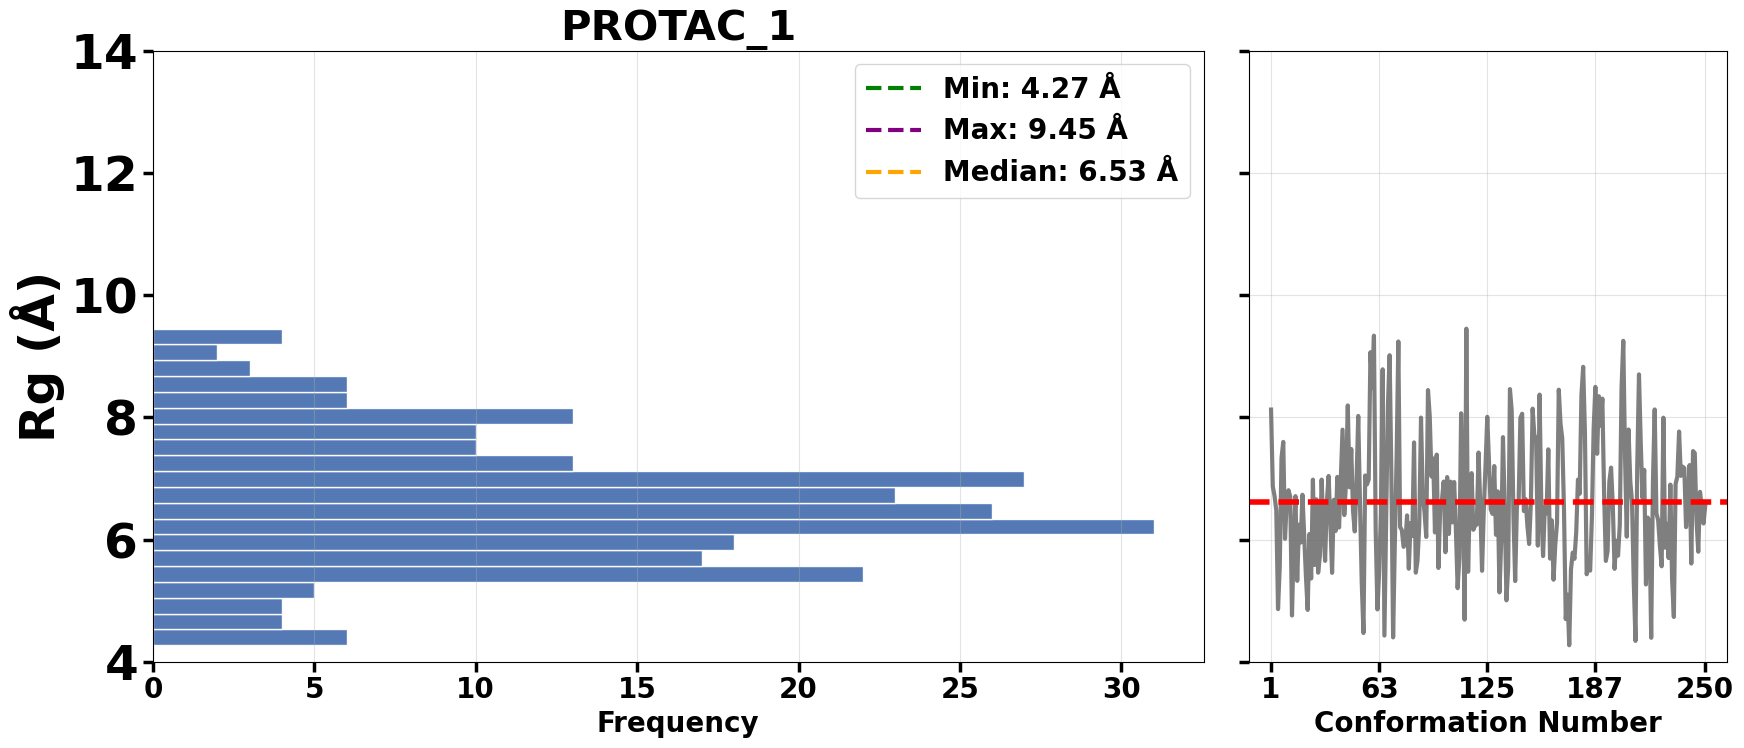

In [11]:
######## Rg Histogram and Line Plot #########
import numpy as np
import matplotlib.pyplot as plt

# Set the limits for the SASA histogram and line plot
XLIM_RG = None  
YLIM_RG = (4, 14)

hist_color = "#4C72B0"

min_rg = df["Rg_A"].min()
max_rg = df["Rg_A"].max()
median_rg = df["Rg_A"].median()
mean_rg = df["Rg_A"].mean()

plt.rcParams.update({
    "font.size": 24,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 30,
    "axes.labelsize": 32,
    "xtick.labelsize": 20,
    "ytick.labelsize": 35,
    "legend.fontsize": 20,
})

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]}
)

ax[0].hist(
    df["Rg_A"],
    bins=20,
    orientation="horizontal",
    color=hist_color,
    edgecolor="white",
    alpha=0.95
)

ax[0].plot([], [], color="green", linestyle="--", linewidth=3,
           label=f"Min: {min_rg:.2f} Å")
ax[0].plot([], [], color="purple", linestyle="--", linewidth=3,
           label=f"Max: {max_rg:.2f} Å")
ax[0].plot([], [], color="orange", linestyle="--", linewidth=3,
           label=f"Median: {median_rg:.2f} Å")

ax[0].set_title(f"{protac_name}", fontweight="bold")
ax[0].set_xlabel("Frequency", fontweight="bold", fontsize=20)
ax[0].set_ylabel("Rg (Å)", fontweight="bold", fontsize=35)
ax[0].grid(axis="x", alpha=0.35)
ax[0].legend(loc="upper right")

if YLIM_RG is not None:
    ax[0].set_ylim(YLIM_RG)

if XLIM_RG is not None:
    ax[0].set_xlim(XLIM_RG)

ax[1].plot(
    df.index + 1,
    df["Rg_A"],
    linestyle="-",
    color="dimgray",
    linewidth=3,
    alpha=0.85
)

ax[1].axhline(
    mean_rg,
    color="red",
    linestyle="--",
    linewidth=4
)

#ax[1].set_title("Rg Line Plot", fontweight="bold")
ax[1].set_xlabel("Conformation Number", fontweight="bold", fontsize=20)
ax[1].grid(True, alpha=0.35)

n_ticks = 5
tick_positions = np.linspace(0, len(df) - 1, n_ticks, dtype=int) + 1

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_positions)

for a in ax:
    a.tick_params(axis="x", labelsize=20, width=2.5, length=7)
    a.tick_params(axis="y", labelsize=35, width=2.5, length=7)

    for label in a.get_xticklabels():
        label.set_fontweight("bold")

    for label in a.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    f"rg_histogram_{protac_name}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [12]:
######## 3D PSA Calculation #########

import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdmolfiles
import mdtraj as md
import tempfile
import os

output_csv = f"psa3d_{protac_name.lower()}.csv"


def get_polar_atom_indices(mol):
    """Atoms included: N, O, and H directly attached to N/O."""
    polar_atoms = []

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() in (7, 8):             ###################### N or O 
            polar_atoms.append(atom.GetIdx())

            for neighbor in atom.GetNeighbors():
                if neighbor.GetAtomicNum() == 1:       ####################### and Attached H
                    polar_atoms.append(neighbor.GetIdx())

    return sorted(set(polar_atoms))


def calculate_3d_psa(mol):
    """3D PSA = SASA of N, O, and attached H atoms."""
    polar_atoms = get_polar_atom_indices(mol)

    if not polar_atoms:
        return 0.0

    with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
        pdb_file = tmp.name

    try:
        rdmolfiles.MolToPDBFile(mol, pdb_file)
        traj = md.load(pdb_file)

        sasa = md.shrake_rupley(traj, mode="atom")  # nm²
        psa3d = sasa[0, polar_atoms].sum() * 100.0  # Å²

        return psa3d

    finally:
        if os.path.exists(pdb_file):
            os.remove(pdb_file)


def analyze_sdf(sdf_file):
    suppl = Chem.SDMolSupplier(str(sdf_file), removeHs=False)

    results = []

    for i, mol in enumerate(suppl):
        if mol is None:
            continue

        conformer_id = mol.GetProp("conformer_id") if mol.HasProp("conformer_id") else str(i)
        psa3d = calculate_3d_psa(mol)

        results.append({
            "conformer_id": conformer_id,
            "PSA3D_N_O_attachedH_A2": psa3d
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    return df


df_psa3d = analyze_sdf(sdf_file)

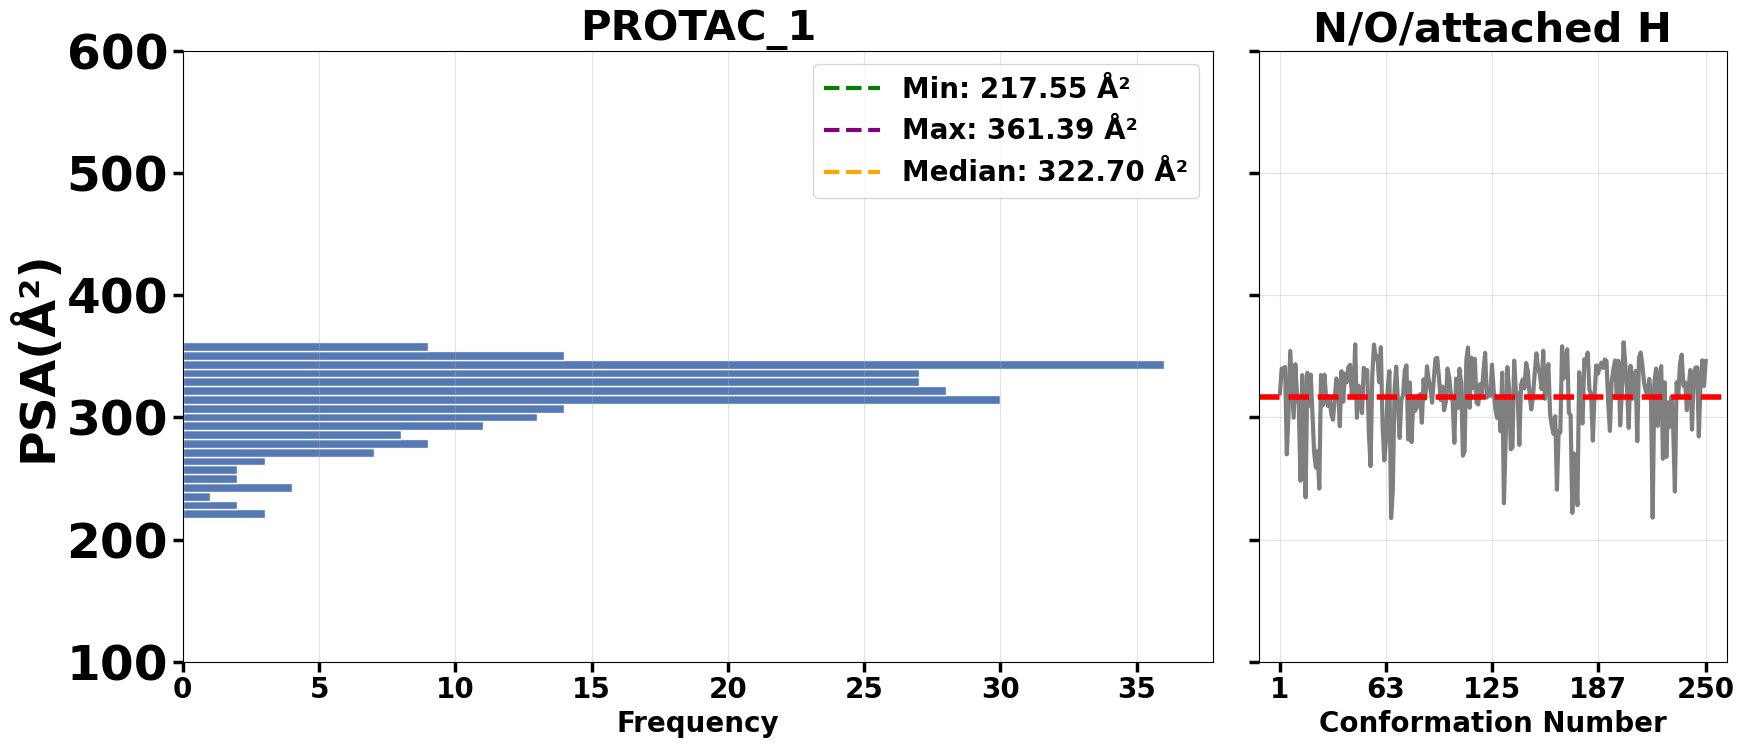

In [13]:
####### PSA Histogram and Line Plot ######### 

import numpy as np
import matplotlib.pyplot as plt

YLIM_PSA = (100, 600)
XLIM_PSA = None

psa_col = "PSA3D_N_O_attachedH_A2"
hist_color = "#4C72B0"

min_psa = df_psa3d[psa_col].min()
max_psa = df_psa3d[psa_col].max()
median_psa = df_psa3d[psa_col].median()
mean_psa = df_psa3d[psa_col].mean()

plt.rcParams.update({
    "font.size": 24,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 30,
    "axes.labelsize": 32,
    "xtick.labelsize": 20,
    "ytick.labelsize": 35,
    "legend.fontsize": 20,
})

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]}
)

ax[0].hist(
    df_psa3d[psa_col],
    bins=20,
    orientation="horizontal",
    color=hist_color,
    edgecolor="white",
    alpha=0.95
)

ax[0].plot([], [], color="green", linestyle="--", linewidth=3,
           label=f"Min: {min_psa:.2f} Å²")
ax[0].plot([], [], color="purple", linestyle="--", linewidth=3,
           label=f"Max: {max_psa:.2f} Å²")
ax[0].plot([], [], color="orange", linestyle="--", linewidth=3,
           label=f"Median: {median_psa:.2f} Å²")

ax[0].set_title(f"{protac_name}", fontweight="bold")
ax[0].set_xlabel("Frequency", fontweight="bold", fontsize=20)
ax[0].set_ylabel("PSA(Å²)", fontweight="bold", fontsize=35)
ax[0].grid(axis="x", alpha=0.35)
ax[0].legend(loc="upper right")

if YLIM_PSA is not None:
    ax[0].set_ylim(YLIM_PSA)

if XLIM_PSA is not None:
    ax[0].set_xlim(XLIM_PSA)

ax[1].plot(
    df_psa3d.index + 1,
    df_psa3d[psa_col],
    linestyle="-",
    color="dimgray",
    linewidth=3,
    alpha=0.85
)

ax[1].axhline(
    mean_psa,
    color="red",
    linestyle="--",
    linewidth=4
)

ax[1].set_title("N/O/attached H", fontweight="bold") #change in case
ax[1].set_xlabel("Conformation Number", fontweight="bold", fontsize=20)
ax[1].grid(True, alpha=0.35)

n_ticks = 5
tick_positions = np.linspace(0, len(df_psa3d) - 1, n_ticks, dtype=int) + 1

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_positions)

for a in ax:
    a.tick_params(axis="x", labelsize=20, width=2.5, length=7)
    a.tick_params(axis="y", labelsize=35, width=2.5, length=7)

    for label in a.get_xticklabels():
        label.set_fontweight("bold")

    for label in a.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    f"psa3d_histogram_{protac_name}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [14]:
############ Energy Calculation for Conformers #############

from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd

# Load conformers from SDF

suppl = Chem.SDMolSupplier(str(sdf_file), removeHs=False) #removeHs=False

energies = []

for i, mol in enumerate(suppl):
    if mol is None:
        energies.append(None)
        continue
    try:
        # Make sure molecule has conformer
        if mol.GetNumConformers() == 0:
            energies.append(None)
            continue

        # Use MMFF or UFF on existing conformer
        if AllChem.MMFFHasAllMoleculeParams(mol):
            mmff = AllChem.MMFFGetMoleculeForceField(mol, AllChem.MMFFGetMoleculeProperties(mol))
            energy = mmff.CalcEnergy()
        else:
            uff = AllChem.UFFGetMoleculeForceField(mol)
            energy = uff.CalcEnergy()

        energies.append(energy)
    except Exception as e:
        print(f"Error at conformer {i}: {e}")
        energies.append(None)

# Add to CSV
input_csv = f"sasa_rg_{protac_name.lower()}.csv"
df = pd.read_csv(input_csv)

# Add the Energy column
df["Energy"] = energies

# Save 
df.to_csv(f"sasa_rg_energy_{protac_name.lower()}.csv", index=False)
print("✅ Energy calculation updated and saved to", f"sasa_rg_energy_{protac_name.lower()}.csv")


✅ Energy calculation updated and saved to sasa_rg_energy_protac_1.csv


✅ Saved: sasa_rg_energy_protac_1.png


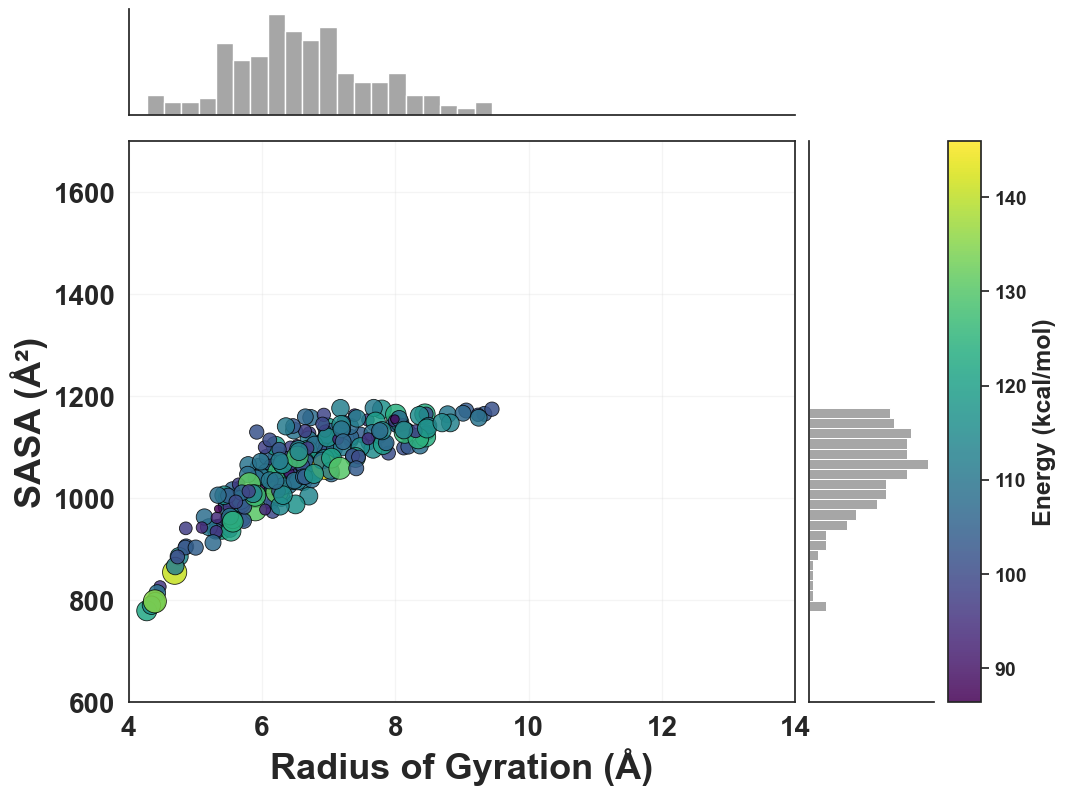

In [15]:
### Histogram and Scatter Plot of SASA, Rg, and Energy ####

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


# OPTIONAL LIMITS
XLIM_RG = (4, 14)
YLIM_SASA = (600, 1700)
ELIM_ENERGY = None 

cmap = "viridis"  # Color map for energy

# Load
df = pd.read_csv(f"sasa_rg_energy_{protac_name.lower()}.csv")
df_clean = df.dropna(subset=["Energy", "Rg_A", "SASA_A2"]).copy()


# Energy filter
if ELIM_ENERGY is not None:
    df_clean = df_clean[
        (df_clean["Energy"] >= ELIM_ENERGY[0]) &
        (df_clean["Energy"] <= ELIM_ENERGY[1])
    ]

if df_clean.empty:
    raise ValueError("No data after filtering.")

energy = df_clean["Energy"]


# Normalize marker size
vmin = energy.min() if ELIM_ENERGY is None else ELIM_ENERGY[0]
vmax = energy.max() if ELIM_ENERGY is None else ELIM_ENERGY[1]

if np.isclose(vmin, vmax):
    size = np.full(len(df_clean), 120)
else:
    norm = (energy - vmin) / (vmax - vmin)
    size = 300 * norm + 30


# Style
sns.set_theme(style="white")

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})


# Layout
fig = plt.figure(figsize=(11, 9))

gs = GridSpec(
    2, 3,
    width_ratios=[8, 1.5, 0.4],
    height_ratios=[1.5, 8],
    wspace=0.05,
    hspace=0.08
)

ax_histx = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
cax = fig.add_subplot(gs[1, 2])


# Scatter
sc = ax.scatter(
    df_clean["Rg_A"],
    df_clean["SASA_A2"],
    c=energy,
    s=size,
    cmap=cmap,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85,
    vmin=vmin,
    vmax=vmax
)

ax.set_xlabel("Radius of Gyration (Å)", fontweight="bold")
ax.set_ylabel("SASA (Å²)", fontweight="bold")

ax.grid(True, alpha=0.2)

# limits
if XLIM_RG is not None:
    ax.set_xlim(XLIM_RG)

if YLIM_SASA is not None:
    ax.set_ylim(YLIM_SASA)


# ticks 
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

ax.tick_params(axis='both', width=2, length=6)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


# histogram (Rg)
sns.histplot(
    x=df_clean["Rg_A"],
    bins=20,
    ax=ax_histx,
    color="gray",
    alpha=0.7,
    edgecolor="white"
)
ax_histx.set_xlabel("")
ax_histx.set_ylabel("")
ax_histx.set_yticks([])
ax_histx.tick_params(axis='x', labelbottom=False)


# histogram (SASA)

sns.histplot(
    y=df_clean["SASA_A2"],
    bins=20,
    ax=ax_histy,
    color="gray",
    alpha=0.7,
    edgecolor="white"
)
ax_histy.set_xlabel("")
ax_histy.set_ylabel("")
ax_histy.set_xticks([])
ax_histy.tick_params(axis='y', labelleft=False)


# Sync limits
ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())


# plot
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label("Energy (kcal/mol)", fontsize=18)
cbar.ax.tick_params(labelsize=14)

for a in [ax_histx, ax_histy]:
    for spine in ["top", "right"]:
        a.spines[spine].set_visible(False)


# Save
output_png = f"sasa_rg_energy_{protac_name.lower()}.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight")

print("✅ Saved:", output_png)

plt.show()

Using PSA column: PSA3D_N_O_attachedH_A2
✅ Saved: psa_rg_energy_protac_1.png


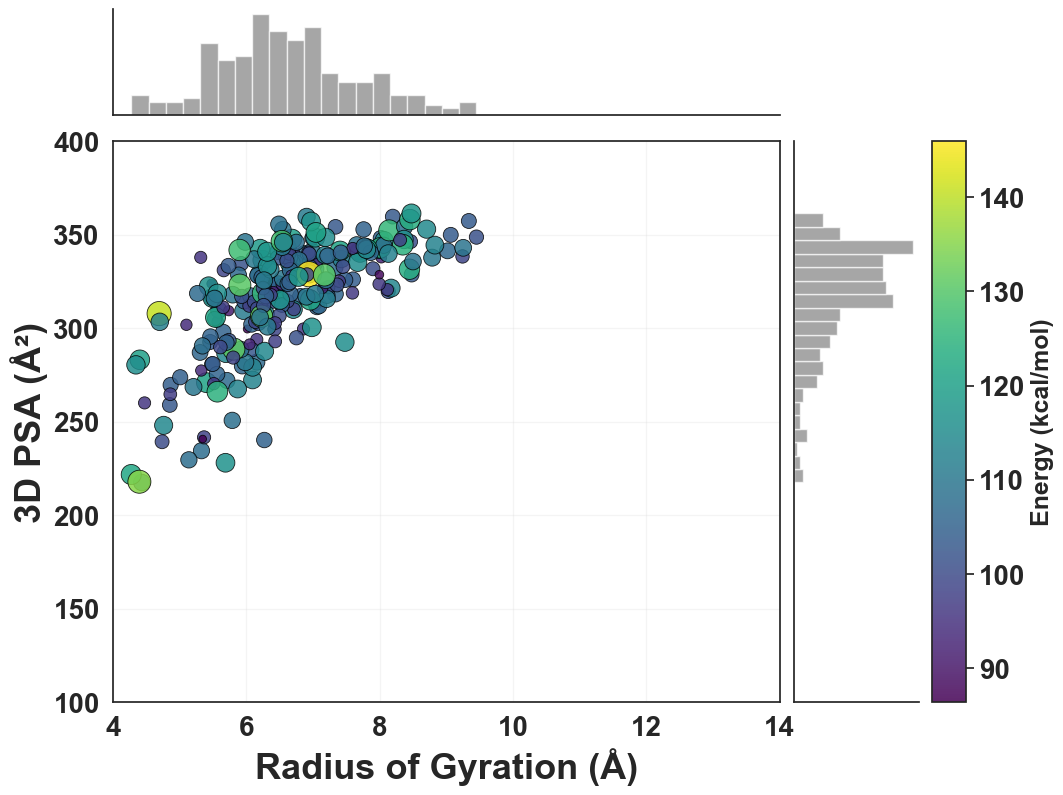

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# OPTIONAL LIMITS
XLIM_RG = (4, 14)        
YLIM_PSA = (100, 400)     
ELIM_ENERGY = None 

cmap = "viridis"  # Color map for energy


# Load
df_rg_energy = pd.read_csv(f"sasa_rg_energy_{protac_name.lower()}.csv")
df_psa = pd.read_csv(f"psa3d_{protac_name.lower()}.csv")

df_rg_energy["conformer_id"] = df_rg_energy["conformer_id"].astype(str)
df_psa["conformer_id"] = df_psa["conformer_id"].astype(str)

df = pd.merge(df_rg_energy, df_psa, on="conformer_id", how="inner")


# Find PSA column 
possible_psa_cols = [
    "PSA (Å²)",
    "PSA3D (Å²)",
    "PSA3D_N_O_attachedH_A2",
    "PSA3D_A2",
    "TPSA (Å²)"
]

psa_col = None
for col in possible_psa_cols:
    if col in df.columns:
        psa_col = col
        break

if psa_col is None:
    raise ValueError(f"No PSA column found. Available columns are: {df.columns.tolist()}")

print(f"Using PSA column: {psa_col}")

df_clean = df.dropna(subset=["Energy", "Rg_A", psa_col]).copy()


# Energy 
if ELIM_ENERGY is not None:
    df_clean = df_clean[
        (df_clean["Energy"] >= ELIM_ENERGY[0]) &
        (df_clean["Energy"] <= ELIM_ENERGY[1])
    ].copy()

if df_clean.empty:
    raise ValueError("No data after merging/filtering.")

energy = df_clean["Energy"]

vmin = energy.min() if ELIM_ENERGY is None else ELIM_ENERGY[0]
vmax = energy.max() if ELIM_ENERGY is None else ELIM_ENERGY[1]

if np.isclose(vmin, vmax):
    size = np.full(len(df_clean), 120)
else:
    norm = np.clip((energy - vmin) / (vmax - vmin), 0, 1)
    size = 300 * norm + 30


# Style

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

fig = plt.figure(figsize=(11, 9))

gs = GridSpec(
    2, 3,
    width_ratios=[8, 1.5, 0.4],
    height_ratios=[1.5, 8],
    wspace=0.05,
    hspace=0.08
)

ax_histx = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
cax = fig.add_subplot(gs[1, 2])

# Scatter
sc = ax.scatter(
    df_clean["Rg_A"],
    df_clean[psa_col],
    c=energy,
    s=size,
    cmap=cmap,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85,
    vmin=vmin,
    vmax=vmax
)

ax.set_xlabel("Radius of Gyration (Å)", fontweight="bold")
ax.set_ylabel("3D PSA (Å²)", fontweight="bold")
ax.grid(True, alpha=0.2)

if XLIM_RG is not None:
    ax.set_xlim(XLIM_RG)

if YLIM_PSA is not None:
    ax.set_ylim(YLIM_PSA)

ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

ax.tick_params(axis="both", width=2, length=6)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

# Histogram: Rg

ax_histx.hist(
    df_clean["Rg_A"],
    bins=20,
    color="gray",
    alpha=0.7,
    edgecolor="white"
)

ax_histx.set_xlabel("")
ax_histx.set_ylabel("")
ax_histx.set_yticks([])
ax_histx.tick_params(axis="x", labelbottom=False)

# Histogram: PSA

ax_histy.hist(
    df_clean[psa_col],
    bins=20,
    orientation="horizontal",
    color="gray",
    alpha=0.7,
    edgecolor="white"
)

ax_histy.set_xlabel("")
ax_histy.set_ylabel("")
ax_histy.set_xticks([])
ax_histy.tick_params(axis="y", labelleft=False)


ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())


cbar = plt.colorbar(sc, cax=cax)
cbar.set_label("Energy (kcal/mol)", fontsize=18, fontweight="bold")
cbar.ax.tick_params(labelsize=20)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")


for a in [ax_histx, ax_histy]:
    for spine in ["top", "right"]:
        a.spines[spine].set_visible(False)

# Save

output_png = f"psa_rg_energy_{protac_name.lower()}.png"

plt.savefig(output_png, dpi=300, bbox_inches="tight")
print("✅ Saved:", output_png)

plt.show()

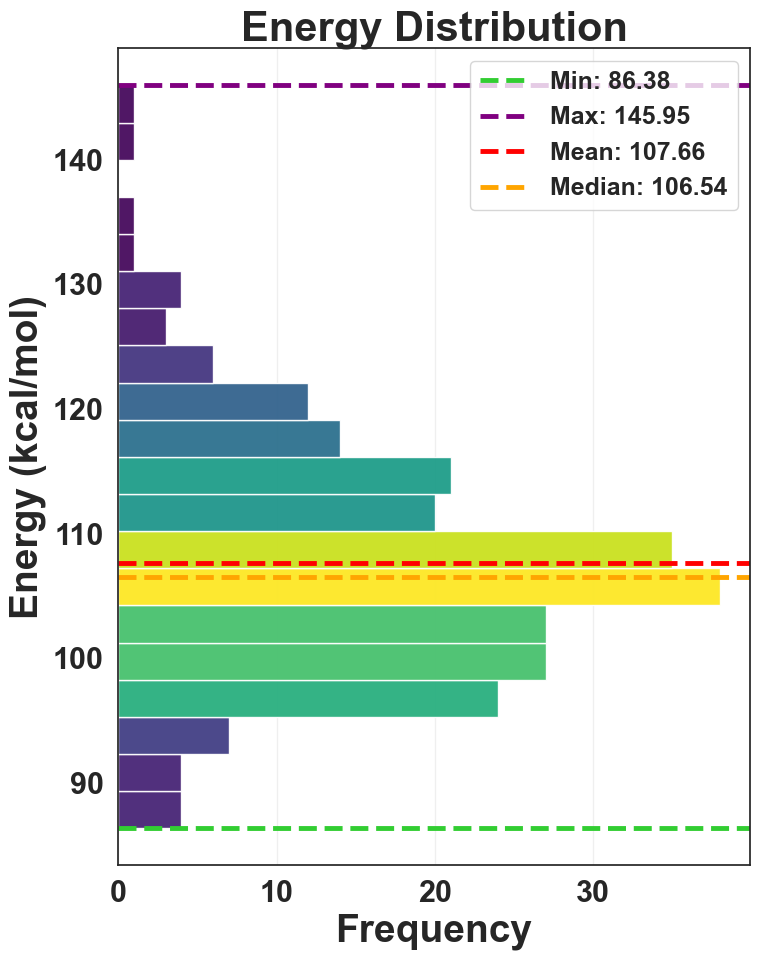

In [17]:
### Energy plot #####

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(f"sasa_rg_energy_{protac_name.lower()}.csv")
df = df.dropna(subset=["Energy"])

energies = df["Energy"]

counts, bins = np.histogram(energies, bins=20)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_width = bins[1] - bins[0]

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 28,
    "axes.titlesize": 30,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})

fig, ax = plt.subplots(figsize=(8, 10))

norm = counts / counts.max()
colors = plt.cm.viridis(norm)

ax.barh(
    bin_centers,
    counts,
    height=bin_width,
    color=colors,
    edgecolor="white",
    alpha=0.95
)

min_e = energies.min()
max_e = energies.max()
mean_e = energies.mean()
median_e = energies.median()

ax.axhline(min_e, color="limegreen", linestyle="--", linewidth=3.5,
           label=f"Min: {min_e:.2f}")
ax.axhline(max_e, color="purple", linestyle="--", linewidth=3.5,
           label=f"Max: {max_e:.2f}")
ax.axhline(mean_e, color="red", linestyle="--", linewidth=3.5,
           label=f"Mean: {mean_e:.2f}")
ax.axhline(median_e, color="orange", linestyle="--", linewidth=3.5,
           label=f"Median: {median_e:.2f}")

ax.set_xlabel("Frequency", fontweight="bold")
ax.set_ylabel("Energy (kcal/mol)", fontweight="bold")
ax.set_title("Energy Distribution", fontweight="bold")

ax.grid(axis="x", alpha=0.3)

ax.tick_params(axis="both", width=2.5, length=7)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(f"energy_histogram_{protac_name.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
## Analyzes intramolecular hydrogen bonds (H-bonds) in a molecule

# ========== SETTINGS ==========
eligible_atoms = [7, 8]  # N and O
# IHB cuttoff
cutoff = 3.0  # H-bond cutoff distance

In [19]:
### Calculate H-bonds for each conformer and generate plots #####

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import acos, degrees
from numpy import dot, linalg
from rdkit import Chem
from rdkit.Chem import rdmolops
from matplotlib.colors import BoundaryNorm
import matplotlib.ticker as ticker
import matplotlib

# ========== 
output_folder = f"{protac_name}_individual_HB_plots"
os.makedirs(output_folder, exist_ok=True)

# ========== 
def calculate_angle(v1, v2):
    cos_theta = dot(v1, v2) / (linalg.norm(v1) * linalg.norm(v2))
    cos_theta = min(1.0, max(-1.0, cos_theta))
    return degrees(acos(cos_theta))

def find_backbone_atoms(mol, atom1_idx, atom2_idx):
    path = rdmolops.GetShortestPath(mol, atom1_idx, atom2_idx)
    return len(path) - 1 if path else 0

def find_intramolecular_hbonds(mol, confId=-1, eligibleAtoms=[7, 8], distTol=3.0):
    res = []
    conf = mol.GetConformer(confId)
    for i in range(mol.GetNumAtoms()):
        atomi = mol.GetAtomWithIdx(i)
        if atomi.GetAtomicNum() != 1 or atomi.GetDegree() != 1:
            continue
        donor_atom = atomi.GetNeighbors()[0]
        if donor_atom.GetAtomicNum() not in eligibleAtoms:
            continue
        donor_pos = conf.GetAtomPosition(donor_atom.GetIdx())
        hydrogen_pos = conf.GetAtomPosition(i)
        for j in range(mol.GetNumAtoms()):
            if j == i:
                continue
            atomj = mol.GetAtomWithIdx(j)
            if atomj.GetAtomicNum() not in eligibleAtoms or mol.GetBondBetweenAtoms(i, j):
                continue
            acceptor_pos = conf.GetAtomPosition(j)
            dist = (hydrogen_pos - acceptor_pos).Length()
            if dist < distTol:
                v1 = hydrogen_pos - donor_pos
                v2 = hydrogen_pos - acceptor_pos
                angle = calculate_angle(v1, v2)
                ring_size = int(find_backbone_atoms(mol, donor_atom.GetIdx(), j) + 2)
                res.append((i + 1, j + 1, dist, angle, ring_size))
    return res

# ========== Load conformers
suppl = Chem.SDMolSupplier(sdf_file, removeHs=False)
mol_count = len([m for m in suppl if m is not None])
print(f"Found {mol_count} conformers in {sdf_file}")

hb_counts = []
all_lengths = []
all_angles = []
all_ring_sizes = []

# ========== analyze each conformer and generate plots
for idx, mol in enumerate(suppl):
    if mol is None:
        continue

    conf_name = f"{protac_name}_conf{idx+1}"
    hbonds_data = find_intramolecular_hbonds(mol, confId=-1, distTol=cutoff, eligibleAtoms=eligible_atoms)
    hb_counts.append(len(hbonds_data))

    if len(hbonds_data) == 0:
        continue

    # Extract
    lengths = [r[2] for r in hbonds_data]
    angles = [r[3] for r in hbonds_data]
    ring_sizes = [int(r[4]) for r in hbonds_data]

    all_lengths.extend(lengths)
    all_angles.extend(angles)
    all_ring_sizes.extend(ring_sizes)

    # ====== Plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

    unique_bins = sorted(set(ring_sizes))
    boundaries = np.arange(min(unique_bins) - 0.5, max(unique_bins) + 1.5, 1)
    n_bins = len(boundaries) - 1
    cmap = matplotlib.colormaps.get_cmap('viridis').resampled(n_bins)
    norm = BoundaryNorm(boundaries, n_bins, clip=True)

    # LEFT SCATTER
    sizes = [100 + 50 * r for r in ring_sizes]
    scatter = ax[0].scatter(
        lengths, angles,
        c=ring_sizes,
        s=sizes,
        cmap=cmap,
        norm=norm,
        edgecolor='black'
    )
    ax[0].set_xlabel('HB Length (Å)')
    ax[0].set_ylabel('HB Angle (°)')
    ax[0].set_title(f'Hydrogen Bonds — {conf_name}_ cutoff:{cutoff}')
    ax[0].grid(True)

    cbar = plt.colorbar(scatter, ax=ax[0], boundaries=boundaries, ticks=unique_bins)
    cbar.set_label('Ring Size (# atoms)')
    cbar.set_ticklabels([str(int(b)) for b in unique_bins])

    # BAR PLOT
    counts = [int(ring_sizes.count(b)) for b in unique_bins]
    bar_colors = [cmap(norm(b)) for b in unique_bins]
    ax[1].bar(unique_bins, counts, color=bar_colors, edgecolor='black')
    ax[1].set_xticks(unique_bins)
    ax[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax[1].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax[1].set_xlabel('Ring Size (# atoms)')
    ax[1].set_ylabel('Count (# H-bonds)')
    ax[1].set_title('Ring Size Distribution')

    plt.tight_layout()
    plot_filename = os.path.join(output_folder, f"{conf_name}_HB_analysis.png")
    plt.savefig(plot_filename, dpi=300)
    plt.close()
    print(f"✅ Saved: {protac_name} conf{idx+1} ({len(hbonds_data)} H-bonds)")

Found 250 conformers in protac1_qm.sdf
✅ Saved: PROTAC_1 conf1 (6 H-bonds)
✅ Saved: PROTAC_1 conf2 (5 H-bonds)
✅ Saved: PROTAC_1 conf3 (6 H-bonds)
✅ Saved: PROTAC_1 conf4 (6 H-bonds)
✅ Saved: PROTAC_1 conf5 (6 H-bonds)
✅ Saved: PROTAC_1 conf6 (7 H-bonds)
✅ Saved: PROTAC_1 conf7 (7 H-bonds)
✅ Saved: PROTAC_1 conf8 (6 H-bonds)
✅ Saved: PROTAC_1 conf9 (7 H-bonds)
✅ Saved: PROTAC_1 conf10 (7 H-bonds)
✅ Saved: PROTAC_1 conf11 (6 H-bonds)
✅ Saved: PROTAC_1 conf12 (7 H-bonds)
✅ Saved: PROTAC_1 conf13 (8 H-bonds)
✅ Saved: PROTAC_1 conf14 (7 H-bonds)
✅ Saved: PROTAC_1 conf15 (6 H-bonds)
✅ Saved: PROTAC_1 conf16 (7 H-bonds)
✅ Saved: PROTAC_1 conf17 (6 H-bonds)
✅ Saved: PROTAC_1 conf18 (6 H-bonds)
✅ Saved: PROTAC_1 conf19 (6 H-bonds)
✅ Saved: PROTAC_1 conf20 (7 H-bonds)
✅ Saved: PROTAC_1 conf21 (7 H-bonds)
✅ Saved: PROTAC_1 conf22 (6 H-bonds)
✅ Saved: PROTAC_1 conf23 (6 H-bonds)
✅ Saved: PROTAC_1 conf24 (7 H-bonds)
✅ Saved: PROTAC_1 conf25 (8 H-bonds)
✅ Saved: PROTAC_1 conf26 (6 H-bonds)
✅ Saved:

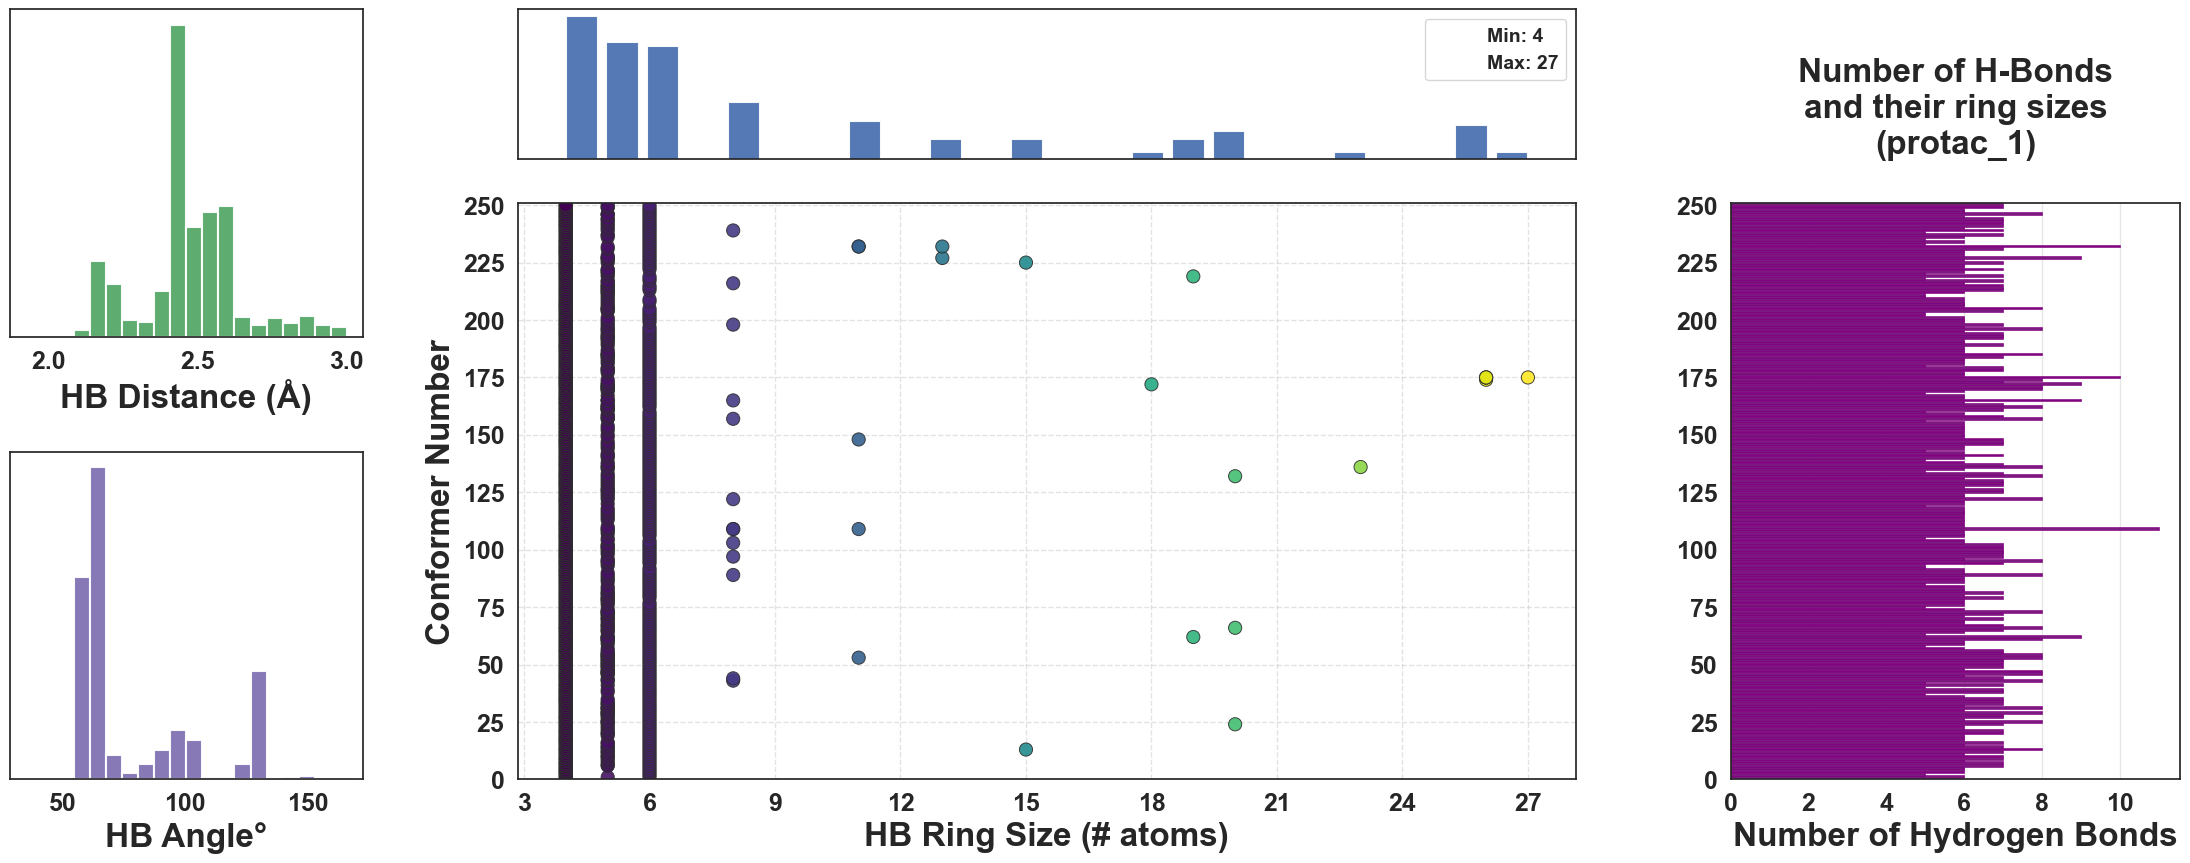

📍 Combined plot saved to: PROTAC_1_individual_HB_plots/PROTAC_1_combined_full_analysis.png


In [20]:
## overall summary HB plot for all conformers ###
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from rdkit import Chem

# ========== Data
ring_values = []
conf_indices = []
all_lengths = []
all_angles = []

suppl = Chem.SDMolSupplier(str(sdf_file), removeHs=False)

for idx, mol in enumerate(suppl):
    if mol is None:
        continue

    hbonds_data = find_intramolecular_hbonds(
        mol,
        confId=-1,
        distTol=cutoff,
        eligibleAtoms=eligible_atoms
    )

    for hbond in hbonds_data:
        ring_values.append(int(hbond[4]))
        conf_indices.append(idx + 1)
        all_lengths.append(hbond[2])
        all_angles.append(hbond[3])

# ========== STYLE ==========
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
})

ring_color = "#4C72B0"
dist_color = "#55A868"
angle_color = "#8172B2"
hb_color = "#6C757D"
edge_color = "#2F2F2F"
grid_color = "#B0B0B0"


fig = plt.figure(figsize=(28, 10))

outer = GridSpec(
    1, 3,
    width_ratios=[1.1, 3.3, 1.4],
    wspace=0.25
)

left_gs = outer[0].subgridspec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.35
)

middle_gs = outer[1].subgridspec(
    2, 1,
    height_ratios=[1.3, 5],
    hspace=0.12
)

right_gs = outer[2].subgridspec(
    2, 1,
    height_ratios=[1.3, 5],
    hspace=0.12
)

ax_dist_hist = fig.add_subplot(left_gs[0, 0])
ax_angle_hist = fig.add_subplot(left_gs[1, 0])

ax_ring_hist = fig.add_subplot(middle_gs[0, 0])
ax_ring_scatter = fig.add_subplot(middle_gs[1, 0])

ax_hb_count = fig.add_subplot(right_gs[1, 0], sharey=ax_ring_scatter)

# ========== LEFT TOP: HB distace
if all_lengths:
    ax_dist_hist.hist(
        all_lengths,
        bins=20,
        color=dist_color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.95
    )

ax_dist_hist.set_title("")
ax_dist_hist.set_xlabel("HB Distance (Å)")
ax_dist_hist.set_ylabel("")
ax_dist_hist.set_yticks([])
ax_dist_hist.grid(axis="y", color=grid_color, alpha=0.3)

# ========== LEFT BOTTOM: HB angle
if all_angles:
    ax_angle_hist.hist(
        all_angles,
        bins=20,
        color=angle_color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.95
    )

ax_angle_hist.set_title("")
ax_angle_hist.set_xlabel("HB Angle°")
ax_angle_hist.set_ylabel("")
ax_angle_hist.set_yticks([])
ax_angle_hist.grid(axis="y", color=grid_color, alpha=0.3)

# ========== TOP MIDDLE: RING size
if ring_values:
    ring_bins = sorted(set(ring_values))
    counts = [ring_values.count(r) for r in ring_bins]

    min_ring = min(ring_values)
    max_ring = max(ring_values)

    ax_ring_hist.bar(
        ring_bins,
        counts,
        color=ring_color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.95
    )

    ax_ring_hist.plot([], [], color="none", label=f"Min: {min_ring}")
    ax_ring_hist.plot([], [], color="none", label=f"Max: {max_ring}")

    ax_ring_hist.set_yscale("log")
    ax_ring_hist.grid(axis="y", color=grid_color, alpha=0.3, which="both")
    #ax_ring_hist.set_title("Ring Size")

    ax_ring_hist.set_xlabel("")
    ax_ring_hist.set_ylabel("")
    ax_ring_hist.set_yticks([])
    ax_ring_hist.tick_params(axis="x", labelbottom=False)
    ax_ring_hist.legend()

# ========== BOTTOM MIDDLE: RING size vs conformer number
if ring_values:
    ring_array = np.array(ring_values)
    norm = (ring_array - ring_array.min()) / (
        ring_array.max() - ring_array.min() + 1e-6
    )
    colors = plt.cm.viridis(norm)
else:
    colors = ring_color

ax_ring_scatter.scatter(
    ring_values,
    conf_indices,
    c=colors,
    edgecolor=edge_color,
    linewidth=0.7,
    alpha=0.9,
    s=90
)

ax_ring_scatter.set_xlabel("HB Ring Size (# atoms)")
ax_ring_scatter.set_ylabel("Conformer Number")
ax_ring_scatter.grid(True, linestyle="--", color=grid_color, alpha=0.35)

if ring_values:
    ax_ring_scatter.set_xticks(range(min(ring_values), max(ring_values) + 1))
    ax_ring_scatter.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ========== RIGHT BOTTOM: HB count
ax_hb_count.barh(
    range(1, len(hb_counts) + 1),
    hb_counts,
    color=hb_color,
    edgecolor="purple",
    linewidth=1.2,
    alpha=0.95
)

ax_hb_count.set_xlabel("Number of Hydrogen Bonds")
ax_hb_count.set_title(
    "Number of H-Bonds\nand their ring sizes\n"
    f"({protac_name.lower()})\n",
    pad=10
)

ax_hb_count.grid(axis="x", color=grid_color, alpha=0.3)
ax_hb_count.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

###
if conf_indices or hb_counts:
    ymax = max(max(conf_indices) if conf_indices else 0, len(hb_counts))

    ax_ring_scatter.set_ylim(0, ymax + 1)
    ax_hb_count.set_ylim(0, ymax + 1)

    step = max(1, ymax // 10)
    yticks = list(range(0, ymax + 1, step))

    if ymax not in yticks:
        yticks.append(ymax)

    ax_ring_scatter.set_yticks(yticks)
    ax_hb_count.set_yticks(yticks)

# ========== Ticks
for ax in [
    ax_dist_hist,
    ax_angle_hist,
    ax_ring_hist,
    ax_ring_scatter,
    ax_hb_count
]:
    ax.tick_params(axis="both", width=2, length=6)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

combined_plot_path = os.path.join(
    output_folder,
    f"{protac_name}_combined_full_analysis.png"
)

plt.savefig(combined_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"📍 Combined plot saved to: {combined_plot_path}")

In [22]:
import numpy as np
import pandas as pd

# ---- Load 
df_rg_sasa = pd.read_csv(f"sasa_rg_{protac_name.lower()}.csv")
df_psa = pd.read_csv(f"psa3d_{protac_name.lower()}.csv")

df_rg_sasa["conformer_id"] = df_rg_sasa["conformer_id"].astype(str)
df_psa["conformer_id"] = df_psa["conformer_id"].astype(str)

df = pd.merge(df_rg_sasa, df_psa, on="conformer_id", how="inner")

# ---- PSA column 
possible_psa_cols = [
    "PSA (Å²)",
    "PSA3D (Å²)",
    "PSA3D_N_O_attachedH_A2",
    "PSA3D_A2"
]

psa_col = None
for col in possible_psa_cols:
    if col in df.columns:
        psa_col = col
        break

if psa_col is None:
    raise ValueError(f"No PSA column found. Available columns: {df.columns.tolist()}")

print(f"Using PSA column: {psa_col}")

# ----
hb_counts_arr = np.array(hb_counts, dtype=float)
ring_sizes_arr = np.array(all_ring_sizes, dtype=float)
lengths_arr = np.array(all_lengths, dtype=float)
angles_arr = np.array(all_angles, dtype=float)

# ---- 
def get_stats(arr):
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]

    if len(arr) == 0:
        return [np.nan, np.nan, np.nan, np.nan]

    return [
        np.min(arr),
        np.max(arr),
        np.mean(arr),
        np.median(arr)
    ]

# ---- Table
summary_df = pd.DataFrame(
    {
        "SASA (Å²)": get_stats(df["SASA_A2"]),
        "Rg (Å)": get_stats(df["Rg_A"]),
        "PSA (Å²)": get_stats(df[psa_col]),
        "H-bond count": get_stats(hb_counts_arr),
        "Ring size": get_stats(ring_sizes_arr),
        "H-bond distance (Å)": get_stats(lengths_arr),
        "H-bond angle (°)": get_stats(angles_arr),
    },
    index=["Min", "Max", "Mean", "Median"]
).round(3)

# ---- Save
output_csv = f"summary_stats_{protac_name.lower()}.csv"
summary_df.to_csv(output_csv)

display(summary_df)

print(f"✅ Summary saved to {output_csv}")

Using PSA column: PSA3D_N_O_attachedH_A2


,SASA (Å²),Rg (Å),PSA (Å²),H-bond count,Ring size,H-bond distance (Å),H-bond angle (°)
Min,779.586,4.272,217.553,5.000,4.00,1.923,35.129
Max,1177.135,9.450,361.387,11.000,27.00,3.000,165.969
Mean,1055.660,6.607,316.698,6.508,4.68,2.471,80.055
Median,1065.491,6.528,322.697,6.000,4.00,2.451,66.387


✅ Summary saved to summary_stats_protac_1.csv


In [23]:
### find the conformer with the largest ring size (MRS) ####
max_ring_size = 0
max_ring_conf = None

for idx, mol in enumerate(suppl):
    if mol is None:
        continue
    hbonds = find_intramolecular_hbonds(mol, confId=-1, distTol=cutoff, eligibleAtoms=eligible_atoms)
    for _, _, _, _, ring_size in hbonds:
        if ring_size > max_ring_size:
            max_ring_size = ring_size
            max_ring_conf = idx

print(f"🔍 Conformer index {max_ring_conf} has the largest ring size in H-bond: {max_ring_size} atoms")

🔍 Conformer index 174 has the largest ring size in H-bond: 27 atoms


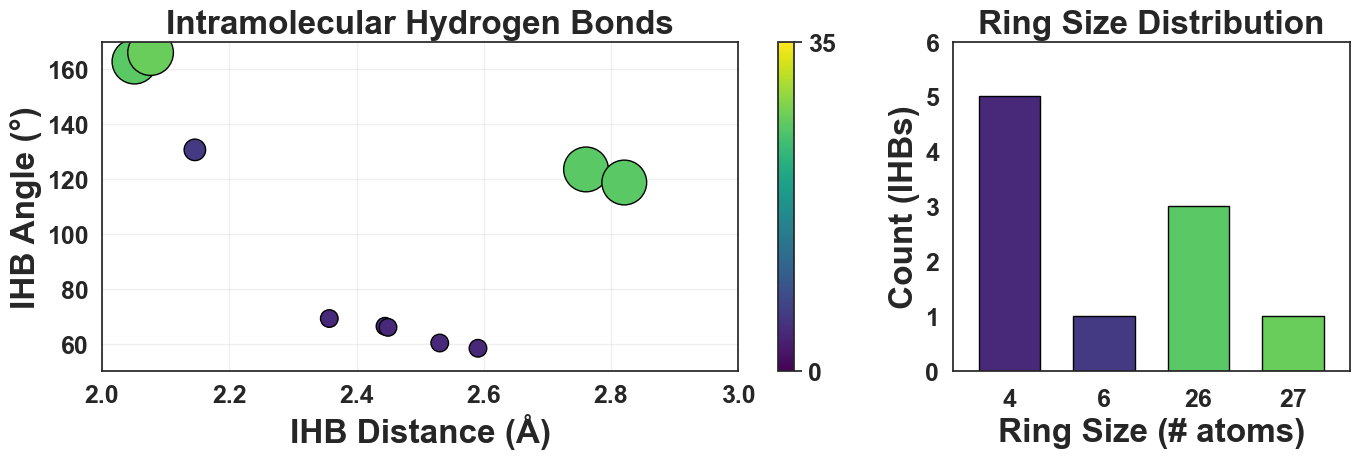

Cutoff: 3.0 Å
Found 10 hydrogen bonds in conformer 175:
Donor H: 63, Acceptor: 18, Distance: 2.59 Å, Angle: 58.4°, Ring size: 4
Donor H: 63, Acceptor: 21, Distance: 2.53 Å, Angle: 60.3°, Ring size: 4
Donor H: 63, Acceptor: 52, Distance: 2.76 Å, Angle: 123.5°, Ring size: 26
Donor H: 63, Acceptor: 54, Distance: 2.05 Å, Angle: 162.7°, Ring size: 26
Donor H: 68, Acceptor: 1, Distance: 2.36 Å, Angle: 69.2°, Ring size: 4
Donor H: 81, Acceptor: 45, Distance: 2.15 Å, Angle: 130.6°, Ring size: 6
Donor H: 90, Acceptor: 18, Distance: 2.08 Å, Angle: 166.0°, Ring size: 27
Donor H: 90, Acceptor: 19, Distance: 2.82 Å, Angle: 118.7°, Ring size: 26
Donor H: 90, Acceptor: 51, Distance: 2.44 Å, Angle: 66.4°, Ring size: 4
Donor H: 90, Acceptor: 54, Distance: 2.45 Å, Angle: 66.0°, Ring size: 4


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from matplotlib.colors import Normalize
from matplotlib import ticker

from rdkit import Chem
from rdkit.Chem import rdmolops


conformer = max_ring_conf + 1
index = max_ring_conf

#### Limits 
distance_xlim = (2, 3.0)
angle_ylim = (50, 170)
count_ylim = (0, 6)
colorbar_range = (0, 35)

# Bar 
ring_axis_padding = 0.6
bar_width = 0.65


# Load

supplier = Chem.SDMolSupplier(
    sdf_file,
    removeHs=False
)

mol = supplier[index]

if mol is None:
    raise ValueError(
        f"Failed to load conformer {conformer} from {sdf_file}"
    )

conf = mol.GetConformer()



# FIND INTRAMOLECULAR H-BONDS
hbonds_data = []

for hydrogen in mol.GetAtoms():

    # Keep explicit hydrogens attached to eligible donor atoms
    if hydrogen.GetAtomicNum() != 1 or hydrogen.GetDegree() != 1:
        continue

    donor = hydrogen.GetNeighbors()[0]

    if donor.GetAtomicNum() not in eligible_atoms:
        continue

    h_idx = hydrogen.GetIdx()
    donor_idx = donor.GetIdx()

    h_pos = conf.GetAtomPosition(h_idx)
    donor_pos = conf.GetAtomPosition(donor_idx)

    for acceptor in mol.GetAtoms():

        acceptor_idx = acceptor.GetIdx()

        if acceptor.GetAtomicNum() not in eligible_atoms:
            continue

        if acceptor_idx == donor_idx:
            continue

        acceptor_pos = conf.GetAtomPosition(acceptor_idx)

        # H···A distance
        distance = (h_pos - acceptor_pos).Length()

        if distance > cutoff:
            continue

        # D–H···A angle
        vector_1 = np.array(h_pos - donor_pos)
        vector_2 = np.array(h_pos - acceptor_pos)

        norm_product = (
            np.linalg.norm(vector_1)
            * np.linalg.norm(vector_2)
        )

        if norm_product == 0:
            continue

        cosine = np.dot(vector_1, vector_2) / norm_product

        angle = np.degrees(
            np.arccos(
                np.clip(cosine, -1.0, 1.0)
            )
        )

        # Pseudo-ring size
        path = rdmolops.GetShortestPath(
            mol,
            donor_idx,
            acceptor_idx
        )

        ring_size = len(path) + 1

        hbonds_data.append([
            h_idx + 1,
            acceptor_idx + 1,
            distance,
            angle,
            ring_size
        ])



# PLOT
if not hbonds_data:

    print(
        f"No hydrogen bonds found in "
        f"{protac_name}, conformer {conformer}."
    )

else:

    lengths = np.array([
        row[2] for row in hbonds_data
    ])

    angles = np.array([
        row[3] for row in hbonds_data
    ])

    ring_sizes = np.array([
        row[4] for row in hbonds_data
    ])

    unique_ring_sizes, counts = np.unique(
        ring_sizes,
        return_counts=True
    )

    color_min, color_max = colorbar_range

    cmap = matplotlib.colormaps["viridis"]

    norm = Normalize(
        vmin=color_min,
        vmax=color_max,
        clip=True
    )

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        gridspec_kw={
            "width_ratios": [2, 1]
        }
    )

    marker_sizes = ring_sizes * 40

    scatter = ax[0].scatter(
        lengths,
        angles,
        c=ring_sizes,
        s=marker_sizes,
        cmap=cmap,
        norm=norm,
        edgecolor="black"
    )

    ax[0].set_xlabel("IHB Distance (Å)")
    ax[0].set_ylabel("IHB Angle (°)")
    ax[0].set_title("Intramolecular Hydrogen Bonds")

    ax[0].set_xlim(distance_xlim)
    ax[0].set_ylim(angle_ylim)

    ax[0].grid(alpha=0.3)

    colorbar = plt.colorbar(
        scatter,
        ax=ax[0],
        ticks=[color_min, color_max]
    )

    colorbar.ax.set_yticklabels([
        str(color_min),
        str(color_max)
    ])

    # Equal spacing between ring-size categories
    x_positions = np.arange(
        len(unique_ring_sizes)
    )

    bar_colors = cmap(
        norm(unique_ring_sizes)
    )

    ax[1].bar(
        x_positions,
        counts,
        width=bar_width,
        color=bar_colors,
        edgecolor="black"
    )

    ax[1].set_xlabel("Ring Size (# atoms)")
    ax[1].set_ylabel("Count (IHBs)")
    ax[1].set_title("Ring Size Distribution")

    # Display actual ring sizes
    ax[1].set_xticks(x_positions)

    ax[1].set_xticklabels([
        str(int(size))
        for size in unique_ring_sizes
    ])

    ax[1].set_xlim(
        -ring_axis_padding,
        len(unique_ring_sizes) - 1 + ring_axis_padding
    )

    ax[1].set_ylim(count_ylim)

    ax[1].tick_params(
        axis="x",
        rotation=0,
        pad=6
    )

    ax[1].yaxis.set_major_locator(
        ticker.MaxNLocator(integer=True)
    )



    # Save

    plt.tight_layout()

    plt.savefig(
        f"{protac_name}_HB_analysis.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


   
    # SUMMARY
    print(f"Cutoff: {cutoff} Å")

    print(
        f"Found {len(hbonds_data)} hydrogen bonds "
        f"in conformer {conformer}:"
    )

    for h, acceptor, distance, angle, ring_size in hbonds_data:

        print(
            f"Donor H: {h}, "
            f"Acceptor: {acceptor}, "
            f"Distance: {distance:.2f} Å, "
            f"Angle: {angle:.1f}°, "
            f"Ring size: {ring_size}"
        )

In [25]:
## 3D visualization of the conformer with the largest ring size (MRS)
#### All H-bonds are shown as dashed blue lines

import py3Dmol
from rdkit import Chem

# Load conformer
conformer_index = max_ring_conf

suppl = Chem.SDMolSupplier(sdf_file, removeHs=False)
mol = suppl[conformer_index]

# Find H-bonds
hbonds = find_intramolecular_hbonds(
    mol,
    confId=-1,
    distTol=cutoff,
    eligibleAtoms=eligible_atoms
)

mb = Chem.MolToMolBlock(mol)

view = py3Dmol.view(width=600, height=500)
view.addModel(mb, "mol")
view.setStyle({"stick": {}})
view.setBackgroundColor("white")
conf = mol.GetConformer()

for hbond in hbonds:
    donor_idx = hbond[0] - 1
    acceptor_idx = hbond[1] - 1

    donor_pos = conf.GetAtomPosition(donor_idx)
    acceptor_pos = conf.GetAtomPosition(acceptor_idx)

    view.addCylinder({
        "start": {
            "x": donor_pos.x,
            "y": donor_pos.y,
            "z": donor_pos.z
        },
        "end": {
            "x": acceptor_pos.x,
            "y": acceptor_pos.y,
            "z": acceptor_pos.z
        },
        "color": "blue",
        "radius": 0.08,      # increase to 0.15 for thicker lines
        "dashed": True,
        "dashLength": 0.25,
        "gapLength": 0.20,
        "opacity": 0.9,
        "fromCap": False,
        "toCap": False
    })

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [26]:
## 3D visualization of the conformer with the largest ring size (MRS)
#### only responsible H-bond for MRS is shown as dashed blue lines

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import py3Dmol

from IPython.display import display, HTML
from numpy import dot, linalg
from math import degrees, acos
from rdkit import Chem
from rdkit.Chem import rdmolops, rdMolDescriptors, rdmolfiles
import mdtraj as md
import tempfile
import os

# ====== SETTINGS ======
conformer = max_ring_conf + 1
index = max_ring_conf

plot_file = f"{protac_name}_HB_analysis.png"

# ====== LOAD MOLECULE ======
suppl = Chem.SDMolSupplier(sdf_file, removeHs=False)
mol = suppl[index]

if mol is None:
    raise ValueError(f"Failed to load molecule from {sdf_file}")


# ====== FUNCTIONS ======
def calculate_angle(v1, v2):
    cos_theta = dot(v1, v2) / (linalg.norm(v1) * linalg.norm(v2))
    cos_theta = min(1.0, max(-1.0, cos_theta))
    return degrees(acos(cos_theta))


def find_backbone_atoms(mol, atom1_idx, atom2_idx):
    path = rdmolops.GetShortestPath(mol, atom1_idx, atom2_idx)
    return len(path) - 1 if path else 0


def find_intramolecular_hbonds(mol, confId=-1, eligibleAtoms=[7, 8], distTol=3.0):
    res = []
    conf = mol.GetConformer(confId)

    for i in range(mol.GetNumAtoms()):
        atomi = mol.GetAtomWithIdx(i)

        if atomi.GetAtomicNum() != 1 or atomi.GetDegree() != 1:
            continue

        donor_atom = atomi.GetNeighbors()[0]

        if donor_atom.GetAtomicNum() not in eligibleAtoms:
            continue

        donor_pos = conf.GetAtomPosition(donor_atom.GetIdx())
        hydrogen_pos = conf.GetAtomPosition(i)

        for j in range(mol.GetNumAtoms()):
            if j == i:
                continue

            atomj = mol.GetAtomWithIdx(j)

            if atomj.GetAtomicNum() not in eligibleAtoms or mol.GetBondBetweenAtoms(i, j):
                continue

            acceptor_pos = conf.GetAtomPosition(j)
            dist = (hydrogen_pos - acceptor_pos).Length()

            if dist < distTol:
                v1 = hydrogen_pos - donor_pos
                v2 = hydrogen_pos - acceptor_pos
                angle = calculate_angle(v1, v2)
                ring_size = int(find_backbone_atoms(mol, donor_atom.GetIdx(), j) + 2)

                res.append((i + 1, j + 1, dist, angle, ring_size))

    return res


def calculate_radius_of_gyration_rdkit(mol):
    """Radius of gyration returned in Å."""
    return rdMolDescriptors.CalcRadiusOfGyration(mol)


def calculate_sasa(mol):
    """Total SASA using mdtraj, returned in Å²."""
    with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
        pdb_file = tmp.name

    try:
        rdmolfiles.MolToPDBFile(mol, pdb_file)
        traj = md.load(pdb_file)
        sasa = md.shrake_rupley(traj)  # nm²
        return sasa.sum(axis=1)[0] * 100.0  # nm² → Å²

    finally:
        if os.path.exists(pdb_file):
            os.remove(pdb_file)


def get_polar_atom_indices(mol):
    """PSA atoms included: N, O, and H directly attached to N/O."""
    polar_atoms = set()

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() in (7, 8):  # N or O
            polar_atoms.add(atom.GetIdx())

            for neighbor in atom.GetNeighbors():
                if neighbor.GetAtomicNum() == 1:  # H attached to N/O
                    polar_atoms.add(neighbor.GetIdx())

    return sorted(polar_atoms)


def calculate_3d_psa(mol):
    """3D PSA = SASA of N, O, and attached H atoms, returned in Å²."""
    polar_atoms = get_polar_atom_indices(mol)

    if not polar_atoms:
        return 0.0

    with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
        pdb_file = tmp.name

    try:
        rdmolfiles.MolToPDBFile(mol, pdb_file)
        traj = md.load(pdb_file)
        sasa = md.shrake_rupley(traj, mode="atom")  # nm² per atom

        return sasa[0, polar_atoms].sum() * 100.0  # nm² → Å²

    finally:
        if os.path.exists(pdb_file):
            os.remove(pdb_file)


# ====== H-bonds
hbonds_data = find_intramolecular_hbonds(
    mol,
    distTol=cutoff,
    eligibleAtoms=eligible_atoms
)


# ====== Plot
if len(hbonds_data) == 0:
    print(f"No hydrogen bonds found in {protac_name}.")

else:
    lengths = [r[2] for r in hbonds_data]
    angles = [r[3] for r in hbonds_data]
    ring_sizes = [int(r[4]) for r in hbonds_data]

    # ===== 2D PLOT =====
    fig, ax = plt.subplots(
        1, 2,
        figsize=(16, 6),
        gridspec_kw={"width_ratios": [2, 1]}
    )

    unique_bins = sorted(set(ring_sizes))
    boundaries = np.arange(min(unique_bins) - 0.5, max(unique_bins) + 1.5, 1)
    n_bins = len(boundaries) - 1

    cmap = matplotlib.colormaps.get_cmap("viridis").resampled(n_bins)
    norm = matplotlib.colors.BoundaryNorm(boundaries, n_bins, clip=True)

    sizes = [100 + 50 * r for r in ring_sizes]

    scatter = ax[0].scatter(
        lengths,
        angles,
        c=ring_sizes,
        s=sizes,
        cmap=cmap,
        norm=norm,
        edgecolor="black"
    )

    ax[0].set_xlabel("HB Length (Å)")
    ax[0].set_ylabel("HB Angle (°)")
    ax[0].set_title(f"Intramolecular H-Bonds — {protac_name}")
    ax[0].grid(True, alpha=0.35)

    cbar = plt.colorbar(
        scatter,
        ax=ax[0],
        boundaries=boundaries,
        ticks=unique_bins
    )
    cbar.set_label("Ring Size (# atoms)")
    cbar.set_ticklabels([str(int(b)) for b in unique_bins])

    counts = [int(ring_sizes.count(b)) for b in unique_bins]
    bar_colors = [cmap(norm(b)) for b in unique_bins]

    ax[1].bar(
        unique_bins,
        counts,
        color=bar_colors,
        edgecolor="black"
    )

    ax[1].set_xticks(unique_bins)
    ax[1].set_xlabel("Ring Size")
    ax[1].set_ylabel("Count")
    ax[1].set_title("Ring Size Distribution")

    ax[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax[1].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(plot_file, dpi=300, bbox_inches="tight")
    plt.close()

    # ===== Max Ring H-bond
    max_ring_hbond = max(hbonds_data, key=lambda x: x[4])

    donor_idx = max_ring_hbond[0] - 1
    acceptor_idx = max_ring_hbond[1] - 1
    distance = max_ring_hbond[2]
    angle = max_ring_hbond[3]
    ring_size = max_ring_hbond[4]

    sasa_val = calculate_sasa(mol)
    psa_val = calculate_3d_psa(mol)
    rg_val = calculate_radius_of_gyration_rdkit(mol)

    conf = mol.GetConformer()
    donor_pos = conf.GetAtomPosition(donor_idx)
    acceptor_pos = conf.GetAtomPosition(acceptor_idx)

    mb = Chem.MolToMolBlock(mol)

    view = py3Dmol.view(width=420, height=420)
    view.addModel(mb, "mol")
    view.setBackgroundColor("white")

    view.setStyle({
        "stick": {
            "radius": 0.18,
            "colorscheme": "Jmol"
        }
    })

    view.addSphere({
        "center": {"x": donor_pos.x, "y": donor_pos.y, "z": donor_pos.z},
        "radius": 0.35,
        "color": "cyan",
        "opacity": 0.95
    })

    view.addSphere({
        "center": {"x": acceptor_pos.x, "y": acceptor_pos.y, "z": acceptor_pos.z},
        "radius": 0.42,
        "color": "blue",
        "opacity": 0.95
    })

    view.addCylinder({
        "start": {"x": donor_pos.x, "y": donor_pos.y, "z": donor_pos.z},
        "end": {"x": acceptor_pos.x, "y": acceptor_pos.y, "z": acceptor_pos.z},
        "color": "blue",
        "radius": 0.08,
        "dashed": True,
        "dashLength": 0.30,
        "gapLength": 0.18,
        "opacity": 0.95,
        "fromCap": False,
        "toCap": False
    })

    view.zoomTo()

    # ===== Plot and 3D visualization in a single display 
    html_plot = f"""
    <div style="display:flex; gap:16px; align-items:flex-start;">
        <div>
            <h3 style="text-align:center; font-size:16px;">HB Analysis Plot</h3>
            <img src="{plot_file}" style="width:760px;">
        </div>

        <div>
            <h3 style="text-align:center; font-size:16px;">Max Ring H-Bond</h3>
            <div style="width:420px; height:420px;">
                {view._make_html()}
            </div>
        </div>
    </div>
    """

    display(HTML(html_plot))

    # Summary
    print(f"Cutoff: {cutoff}")
    print("PSA3D atoms: N, O, and H directly attached to N/O")
    print(f"🔵 H-bond with max ring size in protac {conformer}:")
    print(f"   ↳ Ring size: {ring_size} atoms")
    print(f"   ↳ Donor H:   {donor_idx + 1}")
    print(f"   ↳ Acceptor:  {acceptor_idx + 1}")
    print(f"   ↳ Distance:  {distance:.2f} Å")
    print(f"   ↳ Angle:     {angle:.1f}°")
    print(f"   ↳ SASA:      {sasa_val:.2f} Å²")
    print(f"   ↳ PSA3D:     {psa_val:.2f} Å²")
    print(f"   ↳ Rg:        {rg_val:.2f} Å")

Cutoff: 3.0
PSA3D atoms: N, O, and H directly attached to N/O
🔵 H-bond with max ring size in protac 175:
   ↳ Ring size: 27 atoms
   ↳ Donor H:   90
   ↳ Acceptor:  18
   ↳ Distance:  2.08 Å
   ↳ Angle:     166.0°
   ↳ SASA:      996.94 Å²
   ↳ PSA3D:     228.10 Å²
   ↳ Rg:        5.69 Å


In [27]:
# ===== Summary Table of Max ring size H-bond structure and properties

summary_df = pd.DataFrame({
    "Rg(Å)": [f"{rg_val:.2f} "],
    "SASA (Å²)": [f"{sasa_val:.2f}"],
    "PSA (Å²)": [f"{psa_val:.2f} "],
    "HB   --   Cutoff (Å)": [f"{int(cutoff)}"],
    #"Conformer": [conformer],
    "Ring size": [f"{ring_size} atoms"],
    #"Donor H": [donor_idx + 1],
    #"Acceptor": [acceptor_idx + 1],
    "Distance (Å)": [f"{distance:.2f}"],
    "Angle°": [f"{angle:.1f}"],
})

display(summary_df.style
        .set_caption("")
        .hide(axis="index")
        .set_properties(**{
            "text-align": "center",
            "font-size": "15px",
            "font-weight": "bold"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "20px"),
                    ("font-weight", "bold")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-size", "15px"),
                    ("font-weight", "bold")
                ]
            },
            {
                "selector": "th:nth-child(3)",
                "props": [
                    ("border-right", "2px solid black")
                ]
            },
            {
                "selector": "td:nth-child(3)",
                "props": [
                    ("border-right", "2px solid black")
                ]
            }
        ]))

Rg(Å),SASA (Å²),PSA (Å²),HB -- Cutoff (Å),Ring size,Distance (Å),Angle°
5.69,996.94,228.10,3,27 atoms,2.08,166.0


In [29]:
# ===== Summary Table of All
import numpy as np
import pandas as pd

# ---- Load 
df_rg_sasa = pd.read_csv(f"sasa_rg_{protac_name.lower()}.csv")
df_psa = pd.read_csv(f"psa3d_{protac_name.lower()}.csv")

df_rg_sasa["conformer_id"] = df_rg_sasa["conformer_id"].astype(str)
df_psa["conformer_id"] = df_psa["conformer_id"].astype(str)

df = pd.merge(df_rg_sasa, df_psa, on="conformer_id", how="inner")

# ---- PSA
possible_psa_cols = [
    "PSA (Å²)",
    "PSA3D (Å²)",
    "PSA3D_N_O_attachedH_A2",
    "PSA3D_A2"
]

psa_col = None
for col in possible_psa_cols:
    if col in df.columns:
        psa_col = col
        break

if psa_col is None:
    raise ValueError(f"No PSA column found. Available columns: {df.columns.tolist()}")

print(f"Using PSA column: {psa_col}")


hb_counts_arr = np.array(hb_counts, dtype=float)
ring_sizes_arr = np.array(all_ring_sizes, dtype=float)
lengths_arr = np.array(all_lengths, dtype=float)
angles_arr = np.array(all_angles, dtype=float)

def get_stats(prefix, arr):
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]

    if len(arr) == 0:
        return {
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_mean": np.nan,
            f"{prefix}_median": np.nan
        }

    return {
        f"{prefix}_min": np.min(arr),
        f"{prefix}_max": np.max(arr),
        f"{prefix}_mean": np.mean(arr),
        f"{prefix}_median": np.median(arr)
    }

# ---- 
summary = {}

summary.update(get_stats("sasa_A2", df["SASA_A2"]))
summary.update(get_stats("rg_A", df["Rg_A"]))
summary.update(get_stats("psa3d_A2", df[psa_col]))
summary.update(get_stats("hb_count", hb_counts_arr))
summary.update(get_stats("ring_size", ring_sizes_arr))
summary.update(get_stats("hb_distance_A", lengths_arr))
summary.update(get_stats("hb_angle_deg", angles_arr))

summary_df = pd.DataFrame([summary]).round(3)

# ---- Save 
output_csv = f"summary_stats_{protac_name.lower()}.csv"
summary_df.to_csv(output_csv, index=False)

display(summary_df)

print(f"✅ Summary saved to {output_csv}")

Using PSA column: PSA3D_N_O_attachedH_A2


,sasa_A2_min,sasa_A2_max,sasa_A2_mean,sasa_A2_median,rg_A_min,rg_A_max,rg_A_mean,rg_A_median,psa3d_A2_min,psa3d_A2_max,...,ring_size_mean,ring_size_median,hb_distance_A_min,hb_distance_A_max,hb_distance_A_mean,hb_distance_A_median,hb_angle_deg_min,hb_angle_deg_max,hb_angle_deg_mean,hb_angle_deg_median
0,1010.325,1532.749,1362.66,1383.37,4.982,11.973,7.996,8.029,154.931,287.735,...,5.853,5.0,1.915,2.999,2.535,2.523,34.967,175.326,107.161,101.499


✅ Summary saved to summary_stats_protac_5.csv
